In [9]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt
import segyio
import segyio.tools
from scipy.signal import correlate
from scipy.stats import spearmanr
from scipy.signal import find_peaks, hilbert

In [10]:
class RickerWaveletGenerator:
    """
    Генератор синтетических сейсмических трасс на основе свёрточной модели.
    """
    
    def __init__(self, wavelet_type='ricker', wavelet_freq=30, dt=0.002, length=0.128):
        """
        Инициализация генератора.

        Параметры:
        ----------
        wavelet_type : str
                тип вейвлета по умолчанию ('ricker', других пока нет)
        wavelet_freq : float
                доминантная частота вейвлета в Гц (чем выше частота, тем уже импульс)
        dt : float
                интервал дискретизации в секундах (шаг по времени)
        length : float
                полная длина вейвлета в секундах по умолчанию (от -length/2 до length/2)
        """
        self.wavelet_type = wavelet_type
        self.wavelet_freq = wavelet_freq
        self.length = length
        self.dt = dt
        
        self.wavelet_time, self.wavelet = self._create_ricker_wavelet()
    
    def _create_ricker_wavelet(self):
        """
        Создание вейвлета Рикера.

        Формула: (1 - 2π²f²t²) * exp(-π²f²t²)
        где f - доминантная частота, t - время
    
        Возвращает:
        ----------
        wavelet_time : np.ndarray
                временная ось вейвлета (от -length/2 до length/2 с шагом dt)
        wavelet : np.ndarray
                амплитуды вейвлета (не нормированные)
        """
        # Временная сетка для импульса
        t = np.arange(-self.length/2, self.length/2, self.dt) #создаёт массив чисел от -self.length/2 (-0.064) до self.length/2 (0.064) с шагом self.dt (0.002 сек)
        f = self.wavelet_freq
        
        # Формула вейвлета Рикера
        tau = np.pi * f * t
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        # Нормализация (максимальная амплитуда = 1)
        #wavelet = wavelet / np.max(np.abs(wavelet))
        
        return t, wavelet
    
    def get_wavelet(self):
        """
        Возвращает импульс источника (вейвлет). Создаёт его, если ещё не создан, иначе возвращает существующий.
    
        Возвращает:
        ----------
        tuple : (wavelet_time, wavelet)
                временная ось и амплитуды вейвлета
        """
        if self.wavelet is None:
            if self.wavelet_type == 'ricker':
                t, w = self._create_ricker_wavelet()
                self.wavelet_time = t
                self.wavelet = w
            else:
                raise ValueError(f"Неподдерживаемый тип вейвлета: {self.wavelet_type}")
        return self.wavelet_time, self.wavelet
    
    def generate_trace(self, reflectivity_series, noise_level=0.0):
        """
        Генерирует сейсмическую трассу по коэффициентам отражения.
    
        Параметры:
        ----------
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения (импульсная характеристика среды); длина массиво определяет длительность трассы в отсчётах
        noise_level : float
                уровень шума (0 = без шума по умолчанию, 0.05 = 5% от RMS сигнала)
    
        Возвращает:
        ----------
        trace : np.ndarray
                синтетическая сейсмическая трасса (результат свёртки)
    
        Алгоритм:
        ----------
        1. Вейвлет
        2. Выполнение свёртки: trace = reflectivity * wavelet
        3. Обрезка до длины исходного ряда
        4. Добавление шума (если необходимо)
        """
        # 1. Импульс источника
        wavelet = self.get_wavelet()
        
        # 2. Свёртка коэффициентов отражения с импульсом
        #    'full' -> полная свёртка, потом обрезаем до длины reflectivity_series
        trace_full = np.convolve(reflectivity_series, wavelet, mode='full')
        
        # 3. Обрезка до нужной длины (сохранение временной оси как у reflectivity_series)
        trace = trace_full[:len(reflectivity_series)]
        
        # 4. Шум (если нужно)
        if noise_level > 0:
            # Оценка RMS сигнала
            rms_signal = np.sqrt(np.mean(trace**2))
            # Генерирация шума
            noise = np.random.randn(len(trace)) * noise_level * rms_signal
            trace = trace + noise
        
        return trace
    
    def plot_wavelet(self):
        """Визуализирует импульс источника (если надо, необязаельно)"""
        wavelet = self.get_wavelet()
        plt.figure(figsize=(5, 2))
        plt.plot(self.wavelet_time, wavelet)
        plt.title(f"Импульс источника по умолчанию ({self.wavelet_type}, freq={self.wavelet_freq} Гц)")
        plt.xlabel("Время (с)")
        plt.ylabel("Амплитуда")
        plt.grid(True)
        plt.show()

In [11]:
class ReflectionCoefficients:
    """
    Расчёт коэффициентов отражения для горизонтально-слоистой среды.
    """
    
    def __init__(self, depths, velocities, densities):
        """    
        Параметры:
        ----------
        depths : np.ndarray
                глубины границ от поверхности (м)
                Например: [500, 1200] — границы на 500м и 1200м - 3 слоя
                Длина = количество границ
        velocities : np.ndarray
                скорости в слоях (м/с)
                Длина = len(depths) + 1 (слой над первой границей + слои между границами + последний слой)
        densities : np.ndarray
                плотности в слоях (кг/м³)
                Длина = len(depths) + 1
        
        Действия:
        ----------
        1. Сохранение входных параметров
        2. Вычисление акустических импедансов слоёв
        3. Вычисление коэффициентов отражения на границах
        4. Вычисление двустороннего времени прихода отражений
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        self.num_layers = len(velocities)
        self.num_boundaries = len(depths)
        
        # Расчёт
        self.impedances = self._compute_impedances()
        self.reflection_coeffs = self._compute_reflection_coeffs()
        self.two_way_times = self._compute_times()
    
    def _compute_impedances(self):
        """
        Вычисляет акустический импеданс для каждого слоя.
    
        Формула: Z = ρ * V
        где ρ - плотность, V - скорость
    
        Возвращает:
        ----------
        impedances : np.ndarray
                массив импедансов для всех слоёв (длина = количество слоёв)
        """
        return self.densities * self.velocities
    
    def _compute_reflection_coeffs(self):
        """
        Вычисляет коэффициент отражения на каждой границе.
    
        Формула: R = (Z₂ - Z₁) / (Z₂ + Z₁)
        где Z₁ - импеданс верхнего слоя, Z₂ - импеданс нижнего слоя
    
        Возвращает:
        ----------
        R : np.ndarray
                массив коэффициентов отражения (длина = количество границ)
            
        Примечание:
        ----------
        R > 0 - отражение положительной полярности (Z₂ > Z₁)
        R < 0 - отражение отрицательной полярности (Z₂ < Z₁)
        """
        R = []
        for i in range(self.num_boundaries):
            Z_upper = self.impedances[i]
            Z_lower = self.impedances[i+1]
            coeff = (Z_lower - Z_upper) / (Z_lower + Z_upper)
            R.append(coeff)
        return np.array(R)
    
    def _compute_times(self):
        """
        Вычисляет двустороннее время прихода отражённой волны от каждой границы.
    
        Принцип:
        ----------
        Время = 2 * (толщина_слоя / скорость_слоя)
        Для каждой границы суммируется время прохождения всех вышележащих слоёв
    
        Возвращает:
        ----------
        times : np.ndarray
            массив времён для каждой границы (в секундах)
        """
        times = []
        cumulative = 0.0
        
        for i in range(self.num_boundaries):
            if i == 0:
                thickness = self.depths[0]
            else:
                thickness = self.depths[i] - self.depths[i-1]
            
            cumulative += 2 * thickness / self.velocities[i]
            times.append(cumulative)
        
        return np.array(times)
    
    def get_reflectivity_series(self, dt, total_time):
        """
        Преобразует коэффициенты отражения в дискретный временной ряд.
    
        Параметры:
        ----------
        dt : float
                интервал дискретизации в секундах
        total_time : float
                полное время записи в секундах
    
        Возвращает:
        ----------
        time_axis : np.ndarray
                временная ось (от 0 до total_time с шагом dt)
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения (импульсы на временах границ)
    
        Примечание:
        ----------
        Коэффициенты отражения размещаются на ближайших временных отсчётах с помощью округления (int(round(t / dt)))
        """
        num_samples = int(total_time / dt) + 1
        time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
        reflectivity = np.zeros(num_samples)
        
        for t, r in zip(self.two_way_times, self.reflection_coeffs):
            idx = int(round(t / dt))
            if idx < num_samples:
                reflectivity[idx] = r
        
        return time_axis, reflectivity
    
    def print_summary(self):
        """Вывод геологической модели в консоль (необязательно)"""
        print("ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ\n")
        
        # Заголовок таблицы
        print(f"{'Слой':<6} {'V (м/с)':<10} {'ρ (кг/м³)':<12} {'Z (кг/(м²·с))':<18} {'Толщина':<12}")
        print("-" * 70)
        
        # Слой 0 (до первой границы)
        print(f"{'0':<6} {self.velocities[0]:<10.0f} {self.densities[0]:<12.1f} {self.impedances[0]:<18.2f} {self.depths[0]:<12.1f} м")
        
        # Промежуточные слои
        for i in range(1, self.num_layers - 1):
            thickness = self.depths[i] - self.depths[i-1]
            print(f"{i:<6} {self.velocities[i]:<10.0f} {self.densities[i]:<12.1f} {self.impedances[i]:<18.2f} {thickness:<12.1f} м")
        
        # Последний слой (полубесконечный)
        if self.num_layers > 1:
            last_thickness = "∞"
            print(f"{self.num_layers-1:<6} {self.velocities[-1]:<10.0f} {self.densities[-1]:<12.1f} {self.impedances[-1]:<18.2f} {last_thickness:<12}")
        
        print("ГРАНИЦЫ\n")
        for i in range(self.num_boundaries):
            sign = "+" if self.reflection_coeffs[i] >= 0 else "-"
            print(f"Граница {i+1}: глубина {self.depths[i]} м, R = {self.reflection_coeffs[i]:.4f} ({sign}), t = {self.two_way_times[i]:.4f} с")


In [12]:
class SeismicTraceGenerator:
    """
    Генератор синтетической трассы.
    """
    
    def __init__(self, wavelet_freq=30, dt=0.002, noise_level=0.0):
        """    
        Создаёт вейвлет с заданными параметрами для последующей свёртки.
        
        Параметры:
        ----------
        wavelet_freq : float
                доминантная частота вейвлета в Гц
        dt : float
                интервал дискретизации в секундах
        noise_level : float
                уровень шума (0 = без шума, 0.05 = 5% от RMS сигнала)
        """
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        self.noise_level = noise_level
        
        # Создание вейвлета с помощью класса RickerWaveletGenerator()
        wavelet = RickerWaveletGenerator(wavelet_freq=wavelet_freq, dt=dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def _add_noise(self, trace):
        """
        Добавляет шум к трассе с уровнем относительно RMS сигнала.
    
        Параметры:
        ----------
        trace : np.ndarray
                входная трасса без шума
    
        Возвращает:
        ----------
        trace_with_noise : np.ndarray
                трасса с добавленным гауссовским шумом
        """
        if self.noise_level <= 0:
            return trace
        
        rms = np.sqrt(np.mean(trace**2))
        if rms > 0:
            noise = np.random.randn(len(trace)) * self.noise_level * rms
            return trace + noise
        return trace
    
    def generate_from_reflectivity(self, reflectivity_series):
        """
        Генерация трассы из временного ряда коэффициентов отражения.
    
        Параметры:
        ----------
        reflectivity_series : np.ndarray
                временной ряд коэффициентов отражения из 
    
        Возвращает:
        ----------
        trace : np.ndarray
                сейсмическая трасса (результат свёртки с вейвлетом)
    
        Примечание:
        ----------
        Используется mode='full' для точного позиционирования импульса,
        затем результат обрезается до длины исходного ряда.
        """
        # Полная свёртка
        trace_full = np.convolve(reflectivity_series, self.wavelet, mode='full')
        
        # Обрезаем до длины исходного ряда
        trace = trace_full[:len(reflectivity_series)]
        
        # Добавляем шум
        trace = self._add_noise(trace)
        
        return trace
    
    def generate_from_model(self, depths, velocities, densities, total_time):
        """
        Полный конвейер: геология → трасса. ГЛАВНАЯ ФУНКЦИЯ ГЕНЕРАЦИИ ТРАССЫ
        
        Возвращает:
        time_axis, trace, rc_model
        """
        # Шаг 1: коэффициенты отражения
        rc = ReflectionCoefficients(depths, velocities, densities)
        
        # Шаг 2: временной ряд коэффициентов
        time_axis, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Шаг 3: свёртка с вейвлетом
        trace = self.generate_from_reflectivity(reflectivity)
        
        return time_axis, trace, rc
    
    def visualize_full(self, depths, velocities, densities, total_time):
        """
        Комплексная визуализация всей цепочки (необязательно):
        1. Скоростная модель
        2. Импедансы слоёв
        3. Коэффициенты отражения
        4. Синтетическая трасса
        """
        # Генерируем трассу
        time_axis, trace, rc = self.generate_from_model(depths, velocities, densities, total_time)
        
        # Получаем временной ряд коэффициентов
        _, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Создаём фигуру из 4 подграфиков
        fig, axes = plt.subplots(4, 1, figsize=(10, 8))
        
        # 1. Скоростная модель
        depths_plot = [0] + list(depths)
        velocities_plot = velocities
        axes[0].step(depths_plot + [depths_plot[-1] + 500], 
                     velocities_plot + [velocities_plot[-1]], 
                     where='post', linewidth=2)
        axes[0].set_ylabel("Скорость V, м/с")
        axes[0].set_xlabel("Глубина, м")
        #axes[0].invert_xaxis()
        axes[0].grid(True)
        axes[0].set_title("1. Скоростная модель")
        
        # 2. Импедансы слоёв
        impedances = rc.impedances
        layer_names = [f"Слой {i+1}" for i in range(len(impedances))]
        axes[1].bar(layer_names, impedances, color='lightblue', edgecolor='black')
        axes[1].set_ylabel("Акустический импеданс Z = ρ·V")
        axes[1].set_title("2. Импедансы слоёв")
        axes[1].grid(True, axis='y')
        
        # 3. Коэффициенты отражения
        R = rc.reflection_coeffs
        boundary_names = [f"Гр.{i+1}" for i in range(len(R))]
        colors = ['green' if r >= 0 else 'red' for r in R]
        axes[2].bar(boundary_names, R, color=colors, edgecolor='black')
        axes[2].axhline(y=0, color='black', linewidth=1)
        axes[2].set_ylabel("Коэффициент отражения R")
        axes[2].set_title("3. Коэффициенты отражения на границах")
        axes[2].grid(True, axis='y')
        
        # 4. Синтетическая трасса
        axes[3].plot(time_axis, trace, 'b-', linewidth=1.5)
        axes[3].set_xlabel("Время, с")
        axes[3].set_ylabel("Амплитуда")
        axes[3].set_title("4. Синтетическая сейсмическая трасса")
        axes[3].grid(True)
        
        # Отмечаем времена прихода границ
        for t in rc.two_way_times:
            axes[3].axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.tight_layout()
        plt.show()
        
        return time_axis, trace, rc


In [13]:
# ПОШЛА ПОПЫТКА

In [14]:
def generate_synthetic_section(num_traces, depths_base, velocities, densities, 
                               horizon_index=1, variation_amplitude=50, 
                               variation_type='sinusoidal',
                               wavelet_freq=30, dt=0.001, total_time=2.0, 
                               noise_level=0.01):
    """
    Генерация синтетического сейсмического разреза с латеральными изменениями (генерация множества трасс по введенным вручную данным)
    
    Параметры:
    ----------
    num_traces : int
        количество трасс в разрезе
    depths_base : list
        базовые глубины границ (м) [граница1, граница2, ...]
    velocities : list
        скорости в слоях (м/с) [слой0, слой1, ...] (len = len(depths_base) + 1)
    densities : list
        плотности в слоях (кг/м³) [слой0, слой1, ...] (len = len(depths_base) + 1)
    horizon_index : int
        индекс горизонта (границы), который будет меняться (0 - первая граница)
    variation_amplitude : float
        амплитуда изменения глубины (м)
    variation_type : str
        тип изменения: 'sinusoidal', 'linear', 'random'
    wavelet_freq : float
        доминантная частота вейвлета (Гц)
    dt : float
        интервал дискретизации (с)
    total_time : float
        полное время записи (с)
    noise_level : float
        уровень шума (0 = без шума)
    
    Возвращает:
    ----------
    traces : np.ndarray
        массив трасс размером (num_traces, num_samples)
    time_axis : np.ndarray
        временная ось
    depths_array : np.ndarray
        массив глубин каждой трассы для изменяющегося горизонта
    """
    
    num_samples = int(total_time / dt) + 1
    time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
    
    # Создание генератора трасс
    trace_gen = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)
    
    # Массив глубин для каждой трассы (рисунок вейвлетов отклонится от прямой)
    x_positions = np.arange(num_traces)
    
    if variation_type == 'sinusoidal':
        # Синусоидальное изменение глубины вдоль профиля
        variation = variation_amplitude * np.sin(2 * np.pi * x_positions / num_traces)
    elif variation_type == 'linear':
        # Линейное изменение
        variation = variation_amplitude * (2 * x_positions / num_traces - 1)
    elif variation_type == 'random':
        # Случайное изменение с плавностью (скользящее среднее)
        variation = np.random.randn(num_traces) * variation_amplitude / 2
        # Сглаживание
        from scipy.ndimage import uniform_filter1d
        variation = uniform_filter1d(variation, size=5)
    else:
        variation = np.zeros(num_traces)
    
    # Глубины для каждой трассы
    depths_array = []
    traces = []
    
    for i in range(num_traces):
        # Копия базовых глубин
        depths_i = depths_base.copy()
        # Изменение выбранного горизонта
        depths_i[horizon_index] = depths_base[horizon_index] + variation[i]
        depths_array.append(depths_i[horizon_index])
        
        # Генерация трасс
        time_axis_i, trace_i, rc_i = trace_gen.generate_from_model(
            depths_i, velocities, densities, total_time
        )
        traces.append(trace_i)
    
    traces = np.array(traces)
    depths_array = np.array(depths_array)
    
    return traces, time_axis, depths_array

In [15]:
depths_base = [300, 700, 1000, 1800]  # 4 границы - 5 слоёв
velocities = [1000, 2200, 1600, 2000, 3500]  # м/с
densities = [1000, 2200, 1400, 2600, 2700]    # кг/м³

num_traces = 100
dt=0.001
horizon_index=2
variation_amplitude=400
variation_type='random'
wavelet_freq=30
total_time=3.0
noise_level=0.1

print("\nГеологическая модель:")
print(f"  Границы на глубинах: {depths_base} м")
print(f"  Скорости в слоях: {velocities} м/с")
print(f"  Плотности в слоях: {densities} кг/м³")


Геологическая модель:
  Границы на глубинах: [300, 700, 1000, 1800] м
  Скорости в слоях: [1000, 2200, 1600, 2000, 3500] м/с
  Плотности в слоях: [1000, 2200, 1400, 2600, 2700] кг/м³


In [16]:
traces, time_axis, depths_changed = generate_synthetic_section(
    num_traces=num_traces,
    depths_base=depths_base,
    velocities=velocities,
    densities=densities,
    horizon_index=horizon_index,  # Меняем третью границу (1000 м) - horizon_index = 2
    variation_amplitude=variation_amplitude,  # Амплитуда ±80 м
    variation_type=variation_type,
    wavelet_freq=wavelet_freq,
    dt=dt,
    total_time=total_time,
    noise_level=noise_level
)

In [17]:
print(f"\nСгенерировано {num_traces} трасс")
print(f"  Отсчётов на трассу: {traces.shape[1]}")
print(f"  Интервал: {dt*1000} мс")
print(f"  Изменение глубины горизонта: от {depths_changed.min():.1f} до {depths_changed.max():.1f} м")


Сгенерировано 100 трасс
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс
  Изменение глубины горизонта: от 791.1 до 1161.5 м


In [18]:
#print([attr for attr in dir(segyio.TraceField) if not attr.startswith('_')])


In [19]:
def save_traces_to_sgy(traces, dt_ms, filename="synthetic_section.sgy", 
                       trace_numbers=None, title="Synthetic Section"):
    """
    Сохранение массива трасс в SEG-Y файл.
    
    Параметры:
    ----------
    traces : np.ndarray
        массив трасс размером (num_traces, num_samples)
    dt_ms : float
        интервал дискретизации в миллисекундах
    filename : str
        имя выходного файла
    trace_numbers : list или np.ndarray, optional
        номера трасс (если None, будут 1, 2, 3, ...)
    title : str
        текстовое описание для заголовка
    
    Возвращает:
    ----------
    filename : str
        имя созданного файла
    """
    
    num_traces, num_samples = traces.shape
    dt_us = int(dt_ms * 1000)
    
    # Создание спецификации файла
    spec = segyio.spec()
    spec.ilines = range(1, num_traces + 1)
    spec.xlines = [1]
    spec.samples = range(num_samples)
    spec.format = 5
    
    with segyio.create(filename, spec) as f:
        
        # Бинарный заголовок
        f.bin[segyio.BinField.Interval] = dt_us
        f.bin[segyio.BinField.Samples] = num_samples
        f.bin[segyio.BinField.Format] = 5
        
        # Текстовый заголовок
        text_header = []
        text_header.append(f"C 1 {title}")
        text_header.append(f"C 2 Created by synthetic seismic generator")
        text_header.append(f"C 3 Number of traces: {num_traces}")
        text_header.append(f"C 4 Samples per trace: {num_samples}")
        text_header.append(f"C 5 Sample interval: {dt_ms} ms ({dt_us} us)")
        text_header.append(f"C 6 Data format: IEEE 32-bit float")
        text_header.append(f"C 7 Date: {np.datetime64('today')}")
        
        while len(text_header) < 40:
            text_header.append(" " * 80)
        
        text_bytes = "\n".join(text_header)[:3200].encode('ascii', errors='ignore')
        f.text[0] = text_bytes.ljust(3200, b' ')
        
        # Трассы и заголовки
        for i in range(num_traces):
            trace_num = i + 1 if trace_numbers is None else trace_numbers[i]
            
            # Данные трассы
            f.trace[i] = traces[i].astype(np.float32)
            
            # Заголовок трассы (существующие поля)
            f.header[i][segyio.TraceField.TraceNumber] = trace_num
            f.header[i][segyio.TraceField.TraceIdentifier] = 1  # 1 = живая трасса
            f.header[i][segyio.TraceField.CDP] = trace_num      # номер CDP (можно использовать как номер трассы)
            f.header[i][segyio.TraceField.CDP_TRACE] = i + 1    # трасса в CDP
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_LINE] = i + 1
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_FILE] = i + 1
    
    print(f"\nФайл сохранён: {filename}")
    print(f"  Трасс: {num_traces}")
    print(f"  Отсчётов на трассу: {num_samples}")
    print(f"  Интервал: {dt_ms} мс ({dt_us} мкс)")
    
    return filename

In [20]:
def save_section_with_metadata(traces, dt, filename="synthetic_section.sgy", 
                                depths_array=None, title="Synthetic Section"):
    """
    Сохранение разреза в SEG-Y с дополнительной информацией. ЭТУ НЕ ПРОВЕРЯЛА
    
    Параметры:
    ----------
    traces : np.ndarray
        Массив трасс
    dt : float
        Интервал дискретизации в СЕКУНДАХ
    filename : str
        Имя файла
    depths_array : np.ndarray, optional
        Массив глубин для записи в заголовок трасс (как вспомогательная информация)
    title : str
        Заголовок
    """
    
    # Конвертируем секунды в миллисекунды
    dt_ms = dt * 1000
    
    num_traces, num_samples = traces.shape
    
    # Создаём спецификацию
    spec = segyio.spec()
    spec.ilines = range(1, num_traces + 1)
    spec.xlines = [1]
    spec.samples = range(num_samples)
    spec.format = 5
    
    with segyio.create(filename, spec) as f:
        
        # Бинарный заголовок
        f.bin[segyio.BinField.Interval] = int(dt_ms * 1000)  # в микросекундах
        f.bin[segyio.BinField.Samples] = num_samples
        f.bin[segyio.BinField.Format] = 5
        
        # Текстовый заголовок
        text_lines = [
            f"C 1 {title}",
            f"C 2 Traces: {num_traces}, Samples: {num_samples}",
            f"C 3 DT: {dt_ms} ms",
            f"C 4 Generated by Python/segyio",
        ]
        if depths_array is not None:
            text_lines.append(f"C 5 Horizon depth varies from {depths_array.min():.1f} to {depths_array.max():.1f} m")
        
        while len(text_lines) < 40:
            text_lines.append(" " * 80)
        
        text_bytes = "\n".join(text_lines)[:3200].encode('ascii', errors='ignore')
        f.text[0] = text_bytes.ljust(3200, b' ')
        
        # Трассы
        for i in range(num_traces):
            f.trace[i] = traces[i].astype(np.float32)
            
            # Заполняем заголовок трассы
            f.header[i][segyio.TraceField.TraceNumber] = i + 1
            f.header[i][segyio.TraceField.TraceIdentifier] = 1
            
            # Если переданы глубины, записываем их в поле для вспомогательной информации
            # (используем поле Coordinate Scale или EnergyLossProduct для хранения глубины)
            if depths_array is not None:
                # Сохраняем глубину как масштабированное целое
                depth_scaled = int(depths_array[i] * 10)  # масштабируем для целого числа
                f.header[i][segyio.TraceField.CDP_X] = depth_scaled  # используем CDP_X для хранения глубины
                f.header[i][segyio.TraceField.CDP_Y] = 0
    
    print(f"\nСохранён файл: {filename}")
    print(f"  Размер: {num_traces} x {num_samples}")
    print(f"  dt = {dt_ms} мс")
    
    return filename

In [13]:
dt_ms = dt * 1000  # dt = 0.001 сек → 1 мс

#Сохранение сгенерированного
save_traces_to_sgy(traces, dt_ms, filename="multilayer_section.sgy",
                   title="5-layer model with sinusoidal variation")


Файл сохранён: multilayer_section.sgy
  Трасс: 100
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс (1000 мкс)


'multilayer_section.sgy'

In [14]:
#=======================================================================================================================================

In [15]:
#=======================================================================================================================================

In [16]:
#=======================================================================================================================================

In [21]:
class RealTraceLoader:
    """
    Загрузчик и анализатор реальных трасс из SEG-Y файла, позволяет загружать трассы, выделять события и анализировать их параметры.
    """
    
    def __init__(self, filename):
        """
        Инициализация загрузчика.
        
        Параметры:
        ----------
        filename : str
            путь к SEG-Y файлу
        """
        self.filename = filename
        self.traces = None      # массив всех трасс
        self.dt_us = None       # интервал дискретизации в микросекундах
        self.dt_ms = None       # интервал дискретизации в миллисекундах
        self.dt_sec = None      # интервал дискретизации в секундах
        self.num_samples = None # количество отсчётов на трассу
        self.num_traces = None  # количество трасс в файле
        self.time_axis = None   # временная ось для трасс (в секундах)
        
        self._load_file_info()
    
    def _load_file_info(self):
        """Загружает информацию о файле без загрузки всех трасс в память."""
        try:
            with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
                self.dt_us = f.bin[segyio.BinField.Interval]
                self.dt_ms = self.dt_us / 1000
                self.dt_sec = self.dt_us / 1_000_000
                self.num_samples = f.bin[segyio.BinField.Samples]
                self.num_traces = len(f.trace)
                
                # Создаём временную ось
                self.time_axis = np.arange(self.num_samples) * self.dt_sec
                
                print(f"SEG-Y файл: {self.filename}")
                print(f"  Трасс: {self.num_traces}")
                print(f"  Отсчётов на трассу: {self.num_samples}")
                print(f"  Интервал: {self.dt_ms} мс ({self.dt_us} мкс)")
                print(f"  Длительность: {self.time_axis[-1]:.2f} с")
        except Exception as e:
            print(f"Ошибка при открытии файла {self.filename}: {e}")
            raise
    
    def load_trace(self, trace_index=0):
        """
        Загружает одну трассу по индексу.
        
        Параметры:
        ----------
        trace_index : int
            номер трассы (начиная с 0)
            
        Возвращает:
        ----------
        trace : np.ndarray
            амплитуды трассы
        """
        if trace_index < 0 or trace_index >= self.num_traces:
            raise ValueError(f"Индекс трассы {trace_index} вне диапазона [0, {self.num_traces - 1}]")
        
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            trace = f.trace[trace_index].astype(np.float32)
        
        print(f"\nЗагружена трасса {trace_index}")
        return trace
    
    def load_multiple_traces(self, trace_indices):
        """
        Загружает несколько трасс.
        
        Параметры:
        ----------
        trace_indices : list
            список индексов трасс
            
        Возвращает:
        ----------
        traces : np.ndarray
            массив трасс размером (len(trace_indices), num_samples)
        """
        traces = []
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            for idx in trace_indices:
                if 0 <= idx < self.num_traces:
                    traces.append(f.trace[idx].astype(np.float32))
                else:
                    print(f"Предупреждение: индекс {idx} вне диапазона, пропускаем")
        
        print(f"\nЗагружено {len(traces)} трасс: {trace_indices}")
        return np.array(traces)
    
    def extract_events(self, trace, prominence=0.05, min_distance=5):
        """
        Выделяет события (пики) на трассе.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса для анализа
        prominence : float
            минимальная значимость пика (относительно RMS сигнала)
        min_distance : int
            минимальное расстояние между пиками в отсчётах
            
        Возвращает:
        ----------
        events : list of dict
            список событий с полями: time, amplitude, type, index
        dominant_freq : float
            оценка доминантной частоты
        """
        # Нормализация трассы для анализа
        trace_norm = trace / (np.std(trace) + 1e-6)
        
        # Пики
        peaks_pos, props_pos = find_peaks(trace_norm, prominence=prominence, distance=min_distance)
        peaks_neg, props_neg = find_peaks(-trace_norm, prominence=prominence, distance=min_distance)
        
        events = []
        
        # Положительные пики
        for p in peaks_pos:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'positive',
                'index': p,
                'prominence': props_pos['prominences'][peaks_pos.tolist().index(p)] if p in peaks_pos else None
            })
        
        # Отрицательные пики
        for p in peaks_neg:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'negative',
                'index': p,
                'prominence': props_neg['prominences'][peaks_neg.tolist().index(p)] if p in peaks_neg else None
            })
        
        # Сортировка по времени
        events.sort(key=lambda x: x['time'])
        
        # Оценка доминантной частоты через огибающую
        analytic = hilbert(trace)
        envelope = np.abs(analytic)
        instantaneous_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi * self.dt_sec)
        
        # Медианная частота в области, где огибающая > 50% от максимума
        strong_mask = envelope[1:] > 0.5 * np.max(envelope)
        if np.any(strong_mask):
            dominant_freq = np.median(instantaneous_freq[strong_mask])
        else:
            dominant_freq = np.median(instantaneous_freq)
        
        print(f"\nАнализ трассы:")
        print(f"  Найдено событий: {len(events)}")
        print(f"  Оценка доминантной частоты: {dominant_freq:.1f} Гц")
        
        return events, dominant_freq
    
    def get_horizons_from_events(self, events, min_amplitude=None, max_events=None):
        """
        Извлекает основные горизонты из списка событий.
        
        Параметры:
        ----------
        events : list
            список событий из extract_events
        min_amplitude : float, optional
            минимальная амплитуда для отбора событий
        max_events : int, optional
            максимальное количество событий для возврата
            
        Возвращает:
        ----------
        horizons : list of dict
            отобранные горизонты (наиболее значимые события)
        """
        # Сортируем по значимости (амплитуде)
        events_sorted = sorted(events, key=lambda x: abs(x['amplitude']), reverse=True)
        
        if min_amplitude is not None:
            events_sorted = [e for e in events_sorted if abs(e['amplitude']) >= min_amplitude]
        
        if max_events is not None and len(events_sorted) > max_events:
            events_sorted = events_sorted[:max_events]
        
        # Сортируем по времени для возврата
        horizons = sorted(events_sorted, key=lambda x: x['time'])
        
        print(f"\nВыделенные горизонты ({len(horizons)}):")
        for i, h in enumerate(horizons):
            print(f"  Горизонт {i+1}: t = {h['time']:.3f} с, A = {h['amplitude']:.3f} ({h['type']})")
        
        return horizons
    
    def compare_traces(self, trace1, trace2):
        """
        Сравнивает две трассы.
        
        Возвращает:
        ----------
        metrics : dict
            метрики сравнения
        """
        min_len = min(len(trace1), len(trace2))
        t1 = trace1[:min_len]
        t2 = trace2[:min_len]
        
        return {
            'pearson': np.corrcoef(t1, t2)[0, 1],
            'spearman': spearmanr(t1, t2)[0],
            'mse': np.mean((t1 - t2)**2),
            'mae': np.mean(np.abs(t1 - t2))
        }
    
    def plot_trace(self, trace, title="Сейсмическая трасса", events=None):
        """
        Визуализирует трассу с отметкой событий.
        
        Параметры:
        ----------
        trace : np.ndarray
            трасса
        title : str
            заголовок графика
        events : list, optional
            список событий для отметки
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.time_axis, trace, 'b-', linewidth=1, label='Трасса')
        
        if events:
            for e in events:
                color = 'r' if e['type'] == 'positive' else 'g'
                plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
                plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", 
                        fontsize=9, ha='center', va='bottom' if e['type'] == 'positive' else 'top')
        
        plt.title(title)
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_multiple_traces(self, traces, titles=None):
        """
        Визуализирует несколько трасс на одном графике для сравнения.
        
        Параметры:
        ----------
        traces : list or np.ndarray
            список трасс или массив трасс
        titles : list, optional
            заголовки для каждой трассы
        """
        if isinstance(traces, np.ndarray) and traces.ndim == 2:
            traces = [traces[i] for i in range(traces.shape[0])]
        
        colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
        
        plt.figure(figsize=(14, 8))
        
        for i, trace in enumerate(traces):
            color = colors[i % len(colors)]
            label = titles[i] if titles and i < len(titles) else f'Трасса {i}'
            plt.plot(self.time_axis[:len(trace)], trace, color=color, 
                    linewidth=1, alpha=0.8, label=label)
        
        plt.title('Сравнение трасс')
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [22]:
# Загрузчик
loader = RealTraceLoader("real_data.sgy")

SEG-Y файл: real_data.sgy
  Трасс: 1343
  Отсчётов на трассу: 1500
  Интервал: 2.0 мс (2000 мкс)
  Длительность: 3.00 с


In [27]:
real_trace = loader.load_trace(trace_index=9)
# 3. События
events, dominant_freq = loader.extract_events(real_trace, prominence=0.05)

# 4. Получаем основные горизонты
horizons = loader.get_horizons_from_events(events, min_amplitude=0.05, max_events=5)


Загружена трасса 9

Анализ трассы:
  Найдено событий: 217
  Оценка доминантной частоты: 41.2 Гц

Выделенные горизонты (5):
  Горизонт 1: t = 0.116 с, A = -6989.777 (negative)
  Горизонт 2: t = 0.126 с, A = 6975.309 (positive)
  Горизонт 3: t = 0.154 с, A = 7536.504 (positive)
  Горизонт 4: t = 0.162 с, A = -7771.797 (negative)
  Горизонт 5: t = 0.178 с, A = -6791.484 (negative)


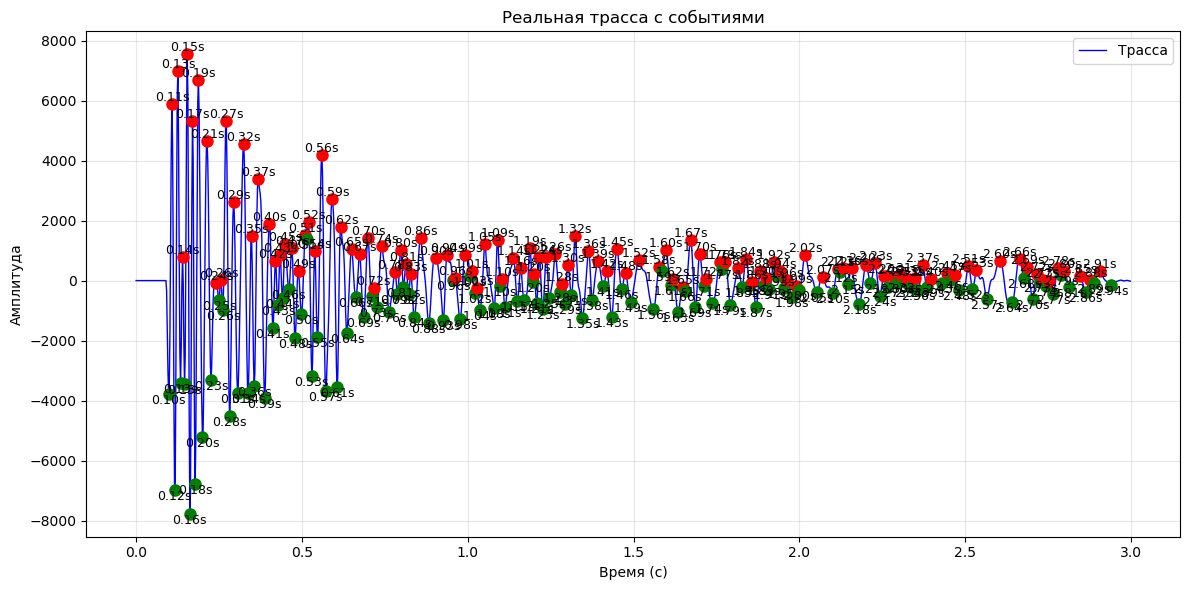

In [29]:
# 5. Визуализируем
loader.plot_trace(real_trace, title="Реальная трасса с событиями", events=events)


Загружено 3 трасс: [0, 100, 200]


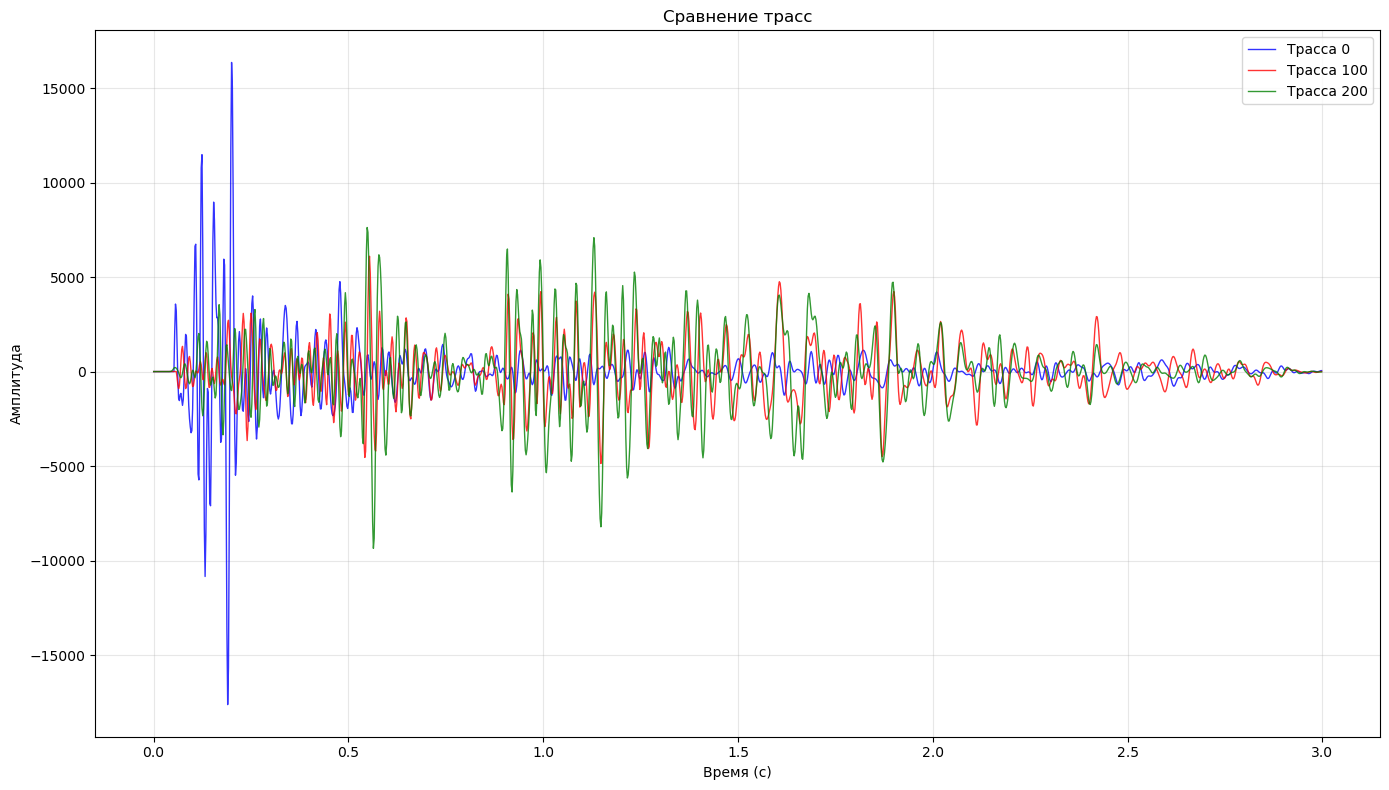

In [24]:
# 6. Сравниваем несколько трасс
traces = loader.load_multiple_traces([0, 100, 200])
loader.plot_multiple_traces(traces, titles=["Трасса 0", "Трасса 100", "Трасса 200"])

In [25]:
# 7. Сравниваем трассы между собой
for i in range(3):
    for j in range(i+1, 3):
        metrics = loader.compare_traces(traces[i], traces[j])
        print(f"Трасса {i} vs {j}: Pearson = {metrics['pearson']:.3f}")

Трасса 0 vs 1: Pearson = -0.025
Трасса 0 vs 2: Pearson = -0.079
Трасса 1 vs 2: Pearson = 0.598


In [136]:
# ПРОГА ОРИЕНТИРУЕТСЯ ОТ ВРЕМЕНИ, НАДО ОТ ОТСЧЕТОВ (на потом)

In [107]:
'''
def generate_section_from_model(num_traces, depths_base, velocities, densities,
                                 horizon_to_vary=1, amplitude=50, 
                                 wavelet_freq=30, dt=0.001, total_time=2.0, 
                                 noise_level=0.0):
    """
    Генерация разреза с использованием классов из try_1.2.
    """
    num_samples = int(total_time / dt) + 1
    time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
    
    # Инициализация генератора
    generator = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)
    
    traces = []
    depths_variation = []
    
    for i in range(num_traces):
        # Создаём вариацию глубины
        variation = amplitude * np.sin(2 * np.pi * i / num_traces)
        
        depths_i = depths_base.copy()
        depths_i[horizon_to_vary] = depths_base[horizon_to_vary] + variation
        
        depths_variation.append(depths_i[horizon_to_vary])
        
        # Генерируем трассу
        _, trace, _ = generator.generate_from_model(depths_i, velocities, densities, total_time)
        traces.append(trace)
    
    return np.array(traces), time_axis, np.array(depths_variation)


# Быстрый тест
traces_section, time_axis_section, depths_var = generate_section_from_model(
    num_traces=80,
    depths_base=[200, 500, 900, 1400, 2000],
    velocities=[1500, 2000, 2500, 3000, 3500, 4000],
    densities=[1800, 2100, 2300, 2500, 2600, 2700],
    horizon_to_vary=2,  # меняем третью границу
    amplitude=60,
    wavelet_freq=35,
    dt=0.001,
    total_time=2.5,
    noise_level=0.01
)

# Визуализация результата
plt.figure(figsize=(12, 8))
plt.imshow(traces_section.T, aspect='auto', cmap='seismic', 
           extent=[0, 80, time_axis_section[-1], 0])
plt.colorbar(label='Амплитуда')
plt.xlabel('Номер трассы')
plt.ylabel('Время (с)')
plt.title('Сейсмический разрез с изменяющейся глубиной горизонта')
plt.show()
'''

'\ndef generate_section_from_model(num_traces, depths_base, velocities, densities,\n                                 horizon_to_vary=1, amplitude=50, \n                                 wavelet_freq=30, dt=0.001, total_time=2.0, \n                                 noise_level=0.0):\n    """\n    Генерация разреза с использованием классов из try_1.2.\n    """\n    num_samples = int(total_time / dt) + 1\n    time_axis = np.arange(0, total_time + dt, dt)[:num_samples]\n\n    # Инициализация генератора\n    generator = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)\n\n    traces = []\n    depths_variation = []\n\n    for i in range(num_traces):\n        # Создаём вариацию глубины\n        variation = amplitude * np.sin(2 * np.pi * i / num_traces)\n\n        depths_i = depths_base.copy()\n        depths_i[horizon_to_vary] = depths_base[horizon_to_vary] + variation\n\n        depths_variation.append(depths_i[horizon_to_vary])\n\n        # Генерируем трассу\n  

ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ

Слой   V (м/с)    ρ (кг/м³)    Z (кг/(м²·с))      Толщина     
----------------------------------------------------------------------
0      1000       1000.0       1000000.00         300.0        м
1      2200       2200.0       4840000.00         400.0        м
2      1600       1400.0       2240000.00         300.0        м
3      2000       2600.0       5200000.00         800.0        м
4      3500       2700.0       9450000.00         ∞           
ГРАНИЦЫ

Граница 1: глубина 300 м, R = 0.6575 (+), t = 0.6000 с
Граница 2: глубина 700 м, R = -0.3672 (-), t = 0.9636 с
Граница 3: глубина 1000 м, R = 0.3978 (+), t = 1.3386 с
Граница 4: глубина 1800 м, R = 0.2901 (+), t = 2.1386 с


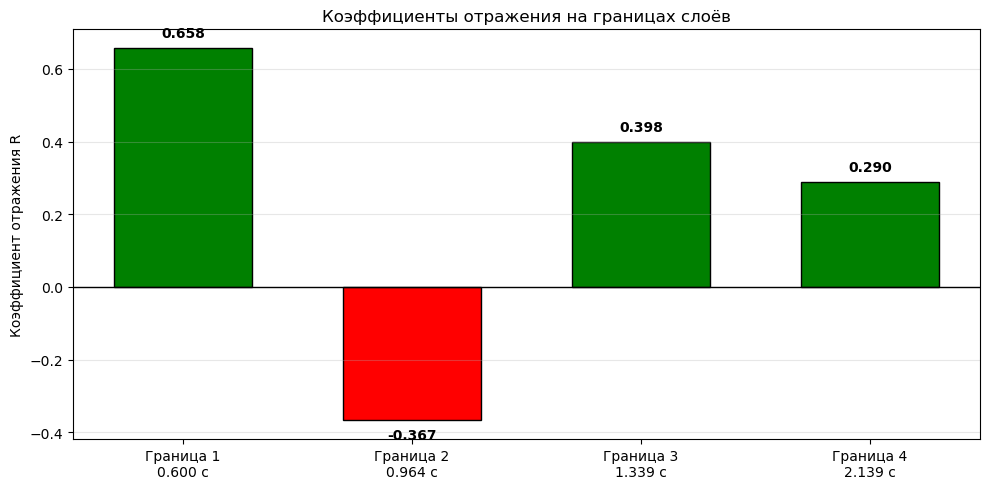

In [23]:
depths = [300, 700, 1000, 1800]  # границы
velocities = [1000, 2200, 1600, 2000, 3500]  # м/с
densities = [1000, 2200, 1400, 2600, 2700]    # кг/м³

rc_model = ReflectionCoefficients(depths, velocities, densities)
rc_model.print_summary()

# Визуализируем коэффициенты отражения
plt.figure(figsize=(10, 5))
boundaries = [f'Граница {i+1}\n{rc_model.two_way_times[i]:.3f} с' for i in range(len(rc_model.reflection_coeffs))]
colors = ['green' if r >= 0 else 'red' for r in rc_model.reflection_coeffs]

plt.bar(boundaries, rc_model.reflection_coeffs, color=colors, edgecolor='black', width=0.6)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.ylabel('Коэффициент отражения R')
plt.title('Коэффициенты отражения на границах слоёв')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for i, (b, r) in enumerate(zip(boundaries, rc_model.reflection_coeffs)):
    plt.text(i, r + (0.03 if r >= 0 else -0.05), f'{r:.3f}', 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('reflection_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

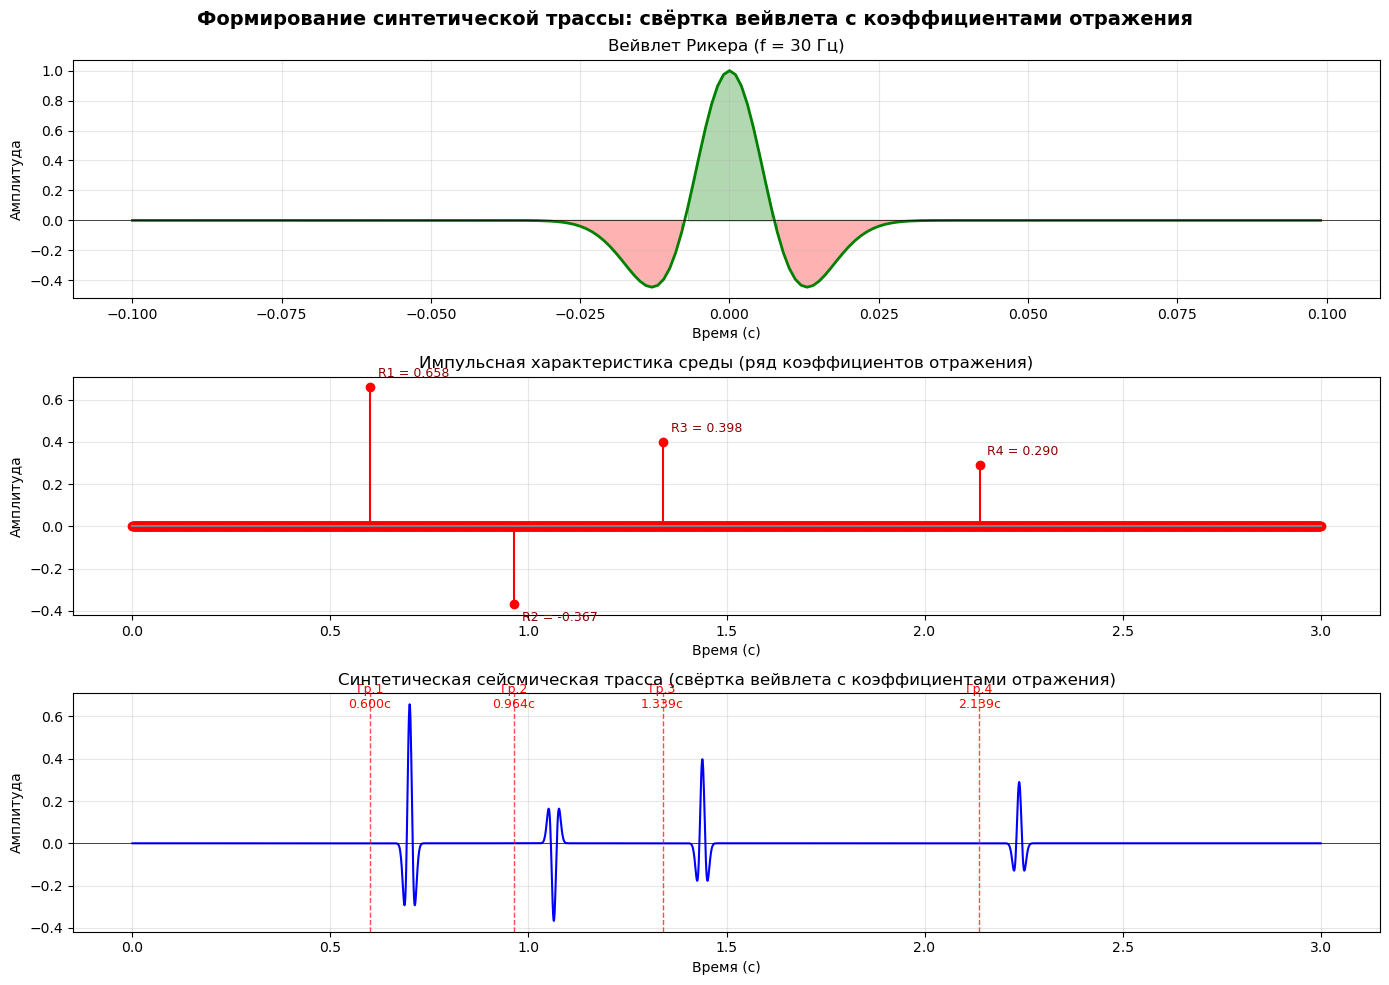

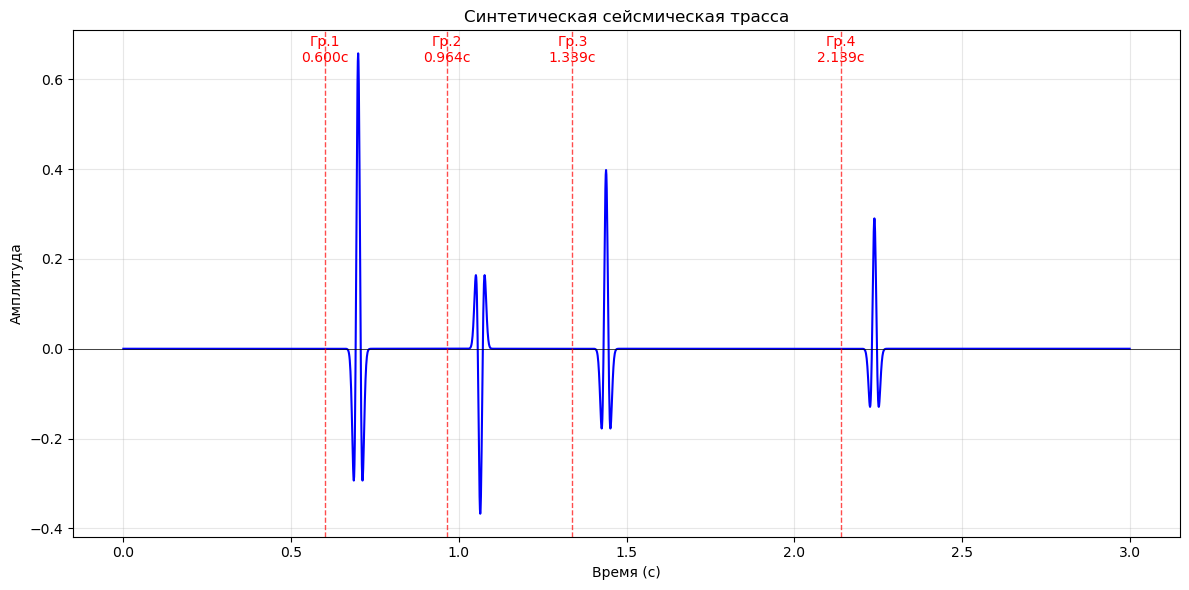

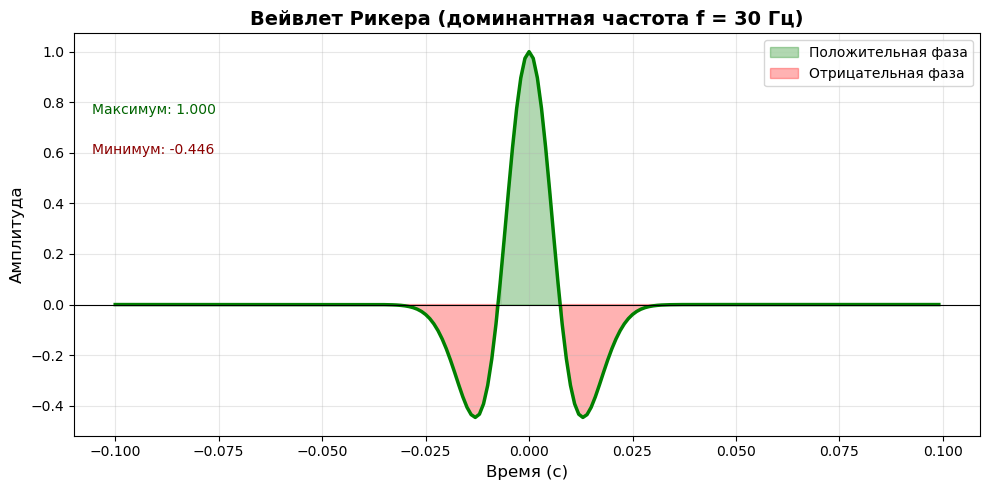


✅ Сохранён отдельный файл: wavelet_only.png

✅ Сохранённые файлы:
   • synthetic_trace_with_wavelet.png - полный график (вейвлет + импульсы + трасса)
   • trace_only.png - отдельный график трассы для презентации


In [31]:
# ========== 3. ГРАФИК ТРАССЫ С ПОКАЗОМ ИСПОЛЬЗОВАННОГО ВЕЙВЛЕТА ==========
# Создаем генератор трасс
trace_gen = SeismicTraceGenerator(wavelet_freq=30, dt=0.001, noise_level=0.0)

# Генерируем трассу
depths = [300, 700, 1000, 1800]
velocities = [1000, 2200, 1600, 2000, 3500]
densities = [1000, 2200, 1400, 2600, 2700]

time_axis, trace, rc = trace_gen.generate_from_model(depths, velocities, densities, total_time=3.0)

# Создаем фигуру с 3 подграфиками
fig = plt.figure(figsize=(14, 10))

# === Подграфик 1: Вейвлет (сверху) ===
ax1 = plt.subplot(3, 1, 1)
wavelet_time = trace_gen.wavelet_time
wavelet = trace_gen.wavelet
ax1.plot(wavelet_time, wavelet, 'g-', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('Амплитуда')
ax1.set_title(f'Вейвлет Рикера (f = {trace_gen.wavelet_freq} Гц)')
ax1.grid(True, alpha=0.3)
# Заливка для наглядности
ax1.fill_between(wavelet_time, wavelet, 0, where=(wavelet >= 0), color='green', alpha=0.3)
ax1.fill_between(wavelet_time, wavelet, 0, where=(wavelet < 0), color='red', alpha=0.3)

# === Подграфик 2: Импульсная характеристика (коэффициенты отражения) ===
ax2 = plt.subplot(3, 1, 2)
_, reflectivity = rc.get_reflectivity_series(0.001, 3.0)
# Используем stems для наглядного отображения импульсов
markerline, stemline, baseline = ax2.stem(time_axis, reflectivity, 
                                           linefmt='r-', markerfmt='ro', 
                                           basefmt='gray')
markerline.set_markersize(6)
stemline.set_linewidth(1.5)
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Амплитуда')
ax2.set_title('Импульсная характеристика среды (ряд коэффициентов отражения)')
ax2.grid(True, alpha=0.3)

# Подписываем значения коэффициентов
for i, t in enumerate(rc.two_way_times):
    r = rc.reflection_coeffs[i]
    y_offset = 0.05 if r >= 0 else -0.08
    ax2.annotate(f'R{i+1} = {r:.3f}', xy=(t, r), xytext=(t + 0.02, r + y_offset),
                 fontsize=9, ha='left', color='darkred')

# === Подграфик 3: Синтетическая трасса (результат свёртки) ===
ax3 = plt.subplot(3, 1, 3)
ax3.plot(time_axis, trace, 'b-', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Время (с)')
ax3.set_ylabel('Амплитуда')
ax3.set_title('Синтетическая сейсмическая трасса (свёртка вейвлета с коэффициентами отражения)')
ax3.grid(True, alpha=0.3)

# Отмечаем времена прихода границ
for i, t in enumerate(rc.two_way_times):
    ax3.axvline(x=t, color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax3.text(t, ax3.get_ylim()[1]*0.9, f'Гр.{i+1}\n{t:.3f}c', 
             ha='center', fontsize=9, color='red')
plt.savefig('wavelet_only.png', dpi=150, bbox_inches='tight')

# Добавляем общую подпись о свёртке
fig.suptitle('Формирование синтетической трассы: свёртка вейвлета с коэффициентами отражения',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('synthetic_trace_with_wavelet.png', dpi=150, bbox_inches='tight')
plt.show()

# Дополнительно: отдельный чистый график только для трассы (для презентации)
plt.figure(figsize=(12, 6))
plt.plot(time_axis, trace, 'b-', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Синтетическая сейсмическая трасса')

# Отмечаем времена прихода границ
for i, t in enumerate(rc.two_way_times):
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.7, linewidth=1)
    plt.text(t, plt.ylim()[1]*0.9, f'Гр.{i+1}\n{t:.3f}c', 
             ha='center', fontsize=10, color='red')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trace_only.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== СОХРАНЕНИЕ ОТДЕЛЬНОГО ГРАФИКА ВЕЙВЛЕТА ==========

# Создаем отдельный чистый график вейвлета (для презентации)
plt.figure(figsize=(10, 5))

# Получаем данные вейвлета из уже созданного генератора
wavelet_time = trace_gen.wavelet_time
wavelet = trace_gen.wavelet

# Рисуем вейвлет
plt.plot(wavelet_time, wavelet, 'g-', linewidth=2.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.title(f'Вейвлет Рикера (доминантная частота f = {trace_gen.wavelet_freq} Гц)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Заливка для наглядности
plt.fill_between(wavelet_time, wavelet, 0, 
                  where=(wavelet >= 0), color='green', alpha=0.3, label='Положительная фаза')
plt.fill_between(wavelet_time, wavelet, 0, 
                  where=(wavelet < 0), color='red', alpha=0.3, label='Отрицательная фаза')

# Добавляем легенду
plt.legend(loc='upper right')

# Отмечаем основные параметры
plt.annotate(f'Максимум: {wavelet.max():.3f}', 
             xy=(wavelet_time[wavelet.argmax()], wavelet.max()),
             xytext=(0.02, 0.8), textcoords='axes fraction',
             fontsize=10, color='darkgreen')

plt.annotate(f'Минимум: {wavelet.min():.3f}', 
             xy=(wavelet_time[wavelet.argmin()], wavelet.min()),
             xytext=(0.02, 0.7), textcoords='axes fraction',
             fontsize=10, color='darkred')

# Сохраняем
plt.tight_layout()
plt.savefig('wavelet_only.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Сохранён отдельный файл: wavelet_only.png")
print("\n✅ Сохранённые файлы:")
print("   • synthetic_trace_with_wavelet.png - полный график (вейвлет + импульсы + трасса)")
print("   • trace_only.png - отдельный график трассы для презентации")

ГЕНЕРАЦИЯ 100 ОДИНАКОВЫХ СИНТЕТИЧЕСКИХ ТРАСС

📋 Параметры:
   • Количество трасс: 100
   • Шаг дискретизации: 1.0 мс
   • Длительность записи: 3.0 с
   • Отсчётов на трассу: 3001
   • Частота вейвлета: 30 Гц
   • Уровень шума: 2.0%

✅ Сгенерировано 100 одинаковых трасс
   • Размер массива: (100, 3001)
   • Минимальная амплитуда: -0.3689
   • Максимальная амплитуда: 0.6585
   • Среднекв. отклонение: 0.0519


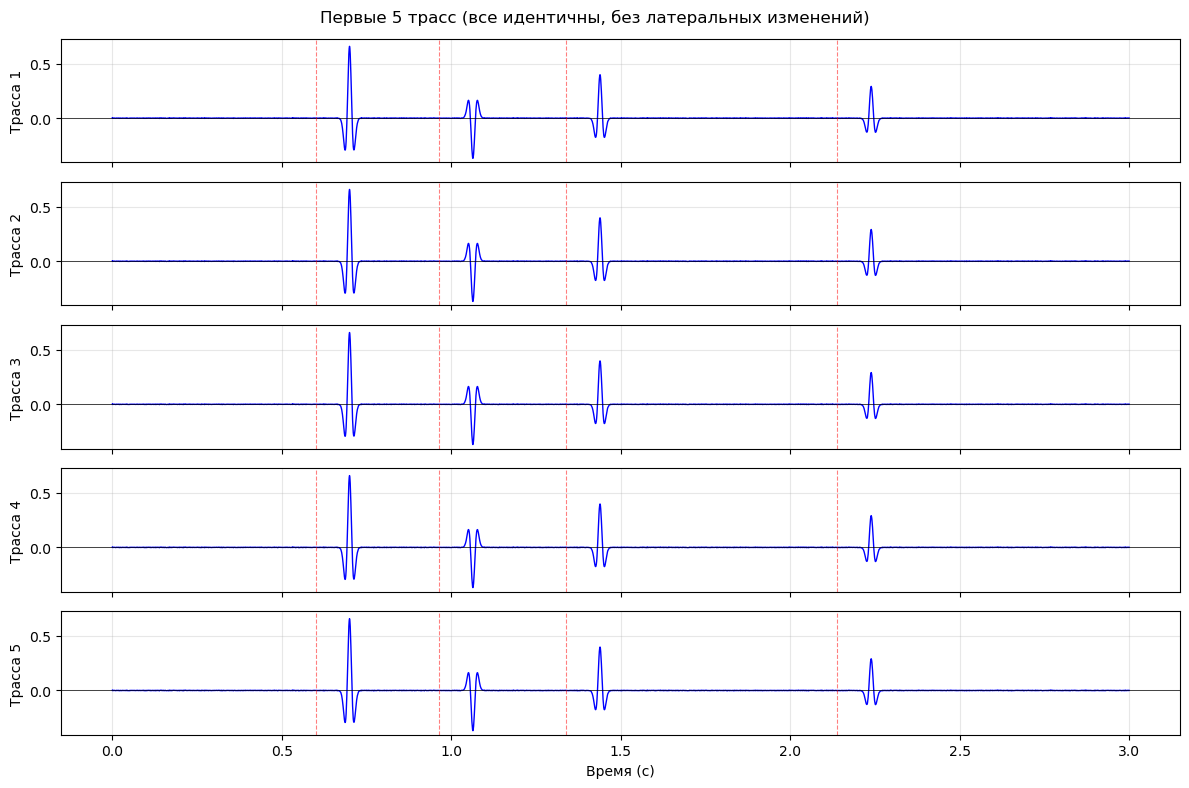

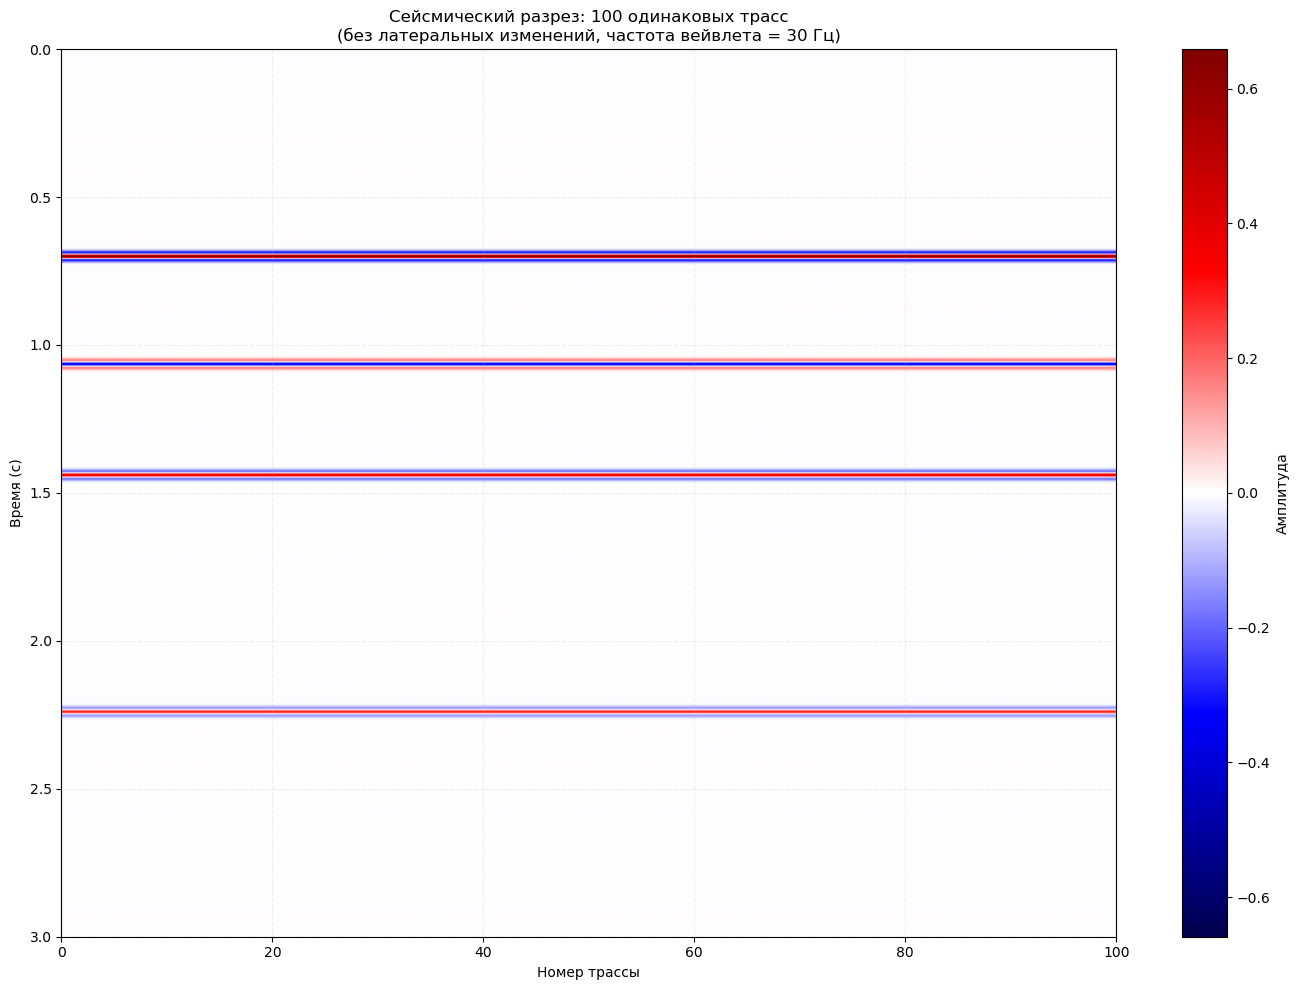


Файл сохранён: identical_traces_section.sgy
  Трасс: 100
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс (1000 мкс)

📊 СТАТИСТИКА ДЛЯ ПРЕЗЕНТАЦИИ

🎛️ ПАРАМЕТРЫ МОДЕЛИ:
   • Количество трасс: 100
   • Отсчётов на трассу: 3001
   • Шаг дискретизации: 1.0 мс
   • Длительность записи: 3.0 с
   • Частота вейвлета: 30 Гц
   • Уровень шума: 2.0%

🏔️ ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ:
   • Количество слоёв: 5
   • Количество границ: 4
   • Глубины границ: [300, 700, 1000, 1800] м
   • Диапазон скоростей: 1000 - 3500 м/с

📈 КОЭФФИЦИЕНТЫ ОТРАЖЕНИЯ:
   • Граница 1 (глубина 300 м): 0.6575 (+)
   • Граница 2 (глубина 700 м): -0.3672 (-)
   • Граница 3 (глубина 1000 м): 0.3978 (+)
   • Граница 4 (глубина 1800 м): 0.2901 (+)

📊 СТАТИСТИКА АМПЛИТУД ТРАСС:
   • Минимальная амплитуда: -0.3689
   • Максимальная амплитуда: 0.6585
   • Максимальная абсолютная амплитуда: 0.6585
   • Среднеквадратичное отклонение (RMS): 0.0519

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   • identical_traces_section.sgy - основной SEG-Y файл
   • identical_tra

In [29]:
# ========== ГЕНЕРАЦИЯ 100 ОДИНАКОВЫХ ТРАСС (БЕЗ ЛАТЕРАЛЬНЫХ ИЗМЕНЕНИЙ) ==========

print("="*60)
print("ГЕНЕРАЦИЯ 100 ОДИНАКОВЫХ СИНТЕТИЧЕСКИХ ТРАСС")
print("="*60)

# Параметры модели
depths_base = [300, 700, 1000, 1800]  # границы
velocities = [1000, 2200, 1600, 2000, 3500]  # м/с
densities = [1000, 2200, 1400, 2600, 2700]    # кг/м³

# Параметры генерации
num_traces = 100
dt = 0.001  # 1 мс
total_time = 3.0  # 2 секунды
wavelet_freq = 30  # Гц
noise_level = 0.02  # 2% шума (немного для реалистичности)

print(f"\n📋 Параметры:")
print(f"   • Количество трасс: {num_traces}")
print(f"   • Шаг дискретизации: {dt*1000} мс")
print(f"   • Длительность записи: {total_time} с")
print(f"   • Отсчётов на трассу: {int(total_time/dt) + 1}")
print(f"   • Частота вейвлета: {wavelet_freq} Гц")
print(f"   • Уровень шума: {noise_level*100}%")

# Создаем генератор трасс
trace_gen = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)

# Генерируем одну базовую трассу
time_axis, base_trace, rc = trace_gen.generate_from_model(
    depths_base, velocities, densities, total_time
)

# Создаем массив из 100 одинаковых трасс
traces_identical = np.tile(base_trace, (num_traces, 1))

print(f"\n✅ Сгенерировано {num_traces} одинаковых трасс")
print(f"   • Размер массива: {traces_identical.shape}")
print(f"   • Минимальная амплитуда: {traces_identical.min():.4f}")
print(f"   • Максимальная амплитуда: {traces_identical.max():.4f}")
print(f"   • Среднекв. отклонение: {traces_identical.std():.4f}")

# ========== ВИЗУАЛИЗАЦИЯ ==========

# 1. Сравнение нескольких трасс (первые 5)
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)
for i in range(5):
    axes[i].plot(time_axis, traces_identical[i], 'b-', linewidth=1)
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[i].set_ylabel(f'Трасса {i+1}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(traces_identical.min()*1.1, traces_identical.max()*1.1)
    
    # Отмечаем границы
    for t in rc.two_way_times:
        axes[i].axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=0.8)

axes[-1].set_xlabel('Время (с)')
fig.suptitle('Первые 5 трасс (все идентичны, без латеральных изменений)', fontsize=12)
plt.tight_layout()
plt.savefig('identical_traces_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Визуализация всего разреза (сейсмограмма)
plt.figure(figsize=(14, 10))
plt.imshow(traces_identical.T, aspect='auto', cmap='seismic', 
           extent=[0, num_traces, total_time, 0],
           vmin=-np.abs(traces_identical).max(), 
           vmax=np.abs(traces_identical).max())
plt.colorbar(label='Амплитуда')
plt.xlabel('Номер трассы')
plt.ylabel('Время (с)')
plt.title(f'Сейсмический разрез: {num_traces} одинаковых трасс\n'
          f'(без латеральных изменений, частота вейвлета = {wavelet_freq} Гц)')
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('identical_section.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== СОХРАНЕНИЕ В SEG-Y ==========

# Сохраняем в SEG-Y файл
dt_ms = dt * 1000  # перевод в миллисекунды
filename = "identical_traces_section.sgy"

save_traces_to_sgy(traces_identical, dt_ms, filename=filename,
                   title=f"Identical traces section: {num_traces} traces, {wavelet_freq} Hz wavelet")

# ========== ДОПОЛНИТЕЛЬНО: СТАТИСТИКА ДЛЯ СЛАЙДА ==========

print("\n" + "="*60)
print("📊 СТАТИСТИКА ДЛЯ ПРЕЗЕНТАЦИИ")
print("="*60)

# Основные метрики
trace_max_abs = np.abs(traces_identical).max()
trace_rms = np.sqrt(np.mean(traces_identical**2))

print(f"\n🎛️ ПАРАМЕТРЫ МОДЕЛИ:")
print(f"   • Количество трасс: {num_traces}")
print(f"   • Отсчётов на трассу: {traces_identical.shape[1]}")
print(f"   • Шаг дискретизации: {dt*1000} мс")
print(f"   • Длительность записи: {total_time} с")
print(f"   • Частота вейвлета: {wavelet_freq} Гц")
print(f"   • Уровень шума: {noise_level*100}%")

print(f"\n🏔️ ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ:")
print(f"   • Количество слоёв: {len(velocities)}")
print(f"   • Количество границ: {len(depths_base)}")
print(f"   • Глубины границ: {depths_base} м")
print(f"   • Диапазон скоростей: {min(velocities)} - {max(velocities)} м/с")

print(f"\n📈 КОЭФФИЦИЕНТЫ ОТРАЖЕНИЯ:")
for i, (depth, r) in enumerate(zip(depths_base, rc.reflection_coeffs)):
    sign = "+" if r >= 0 else "-"
    print(f"   • Граница {i+1} (глубина {depth} м): {r:.4f} ({sign})")

print(f"\n📊 СТАТИСТИКА АМПЛИТУД ТРАСС:")
print(f"   • Минимальная амплитуда: {traces_identical.min():.4f}")
print(f"   • Максимальная амплитуда: {traces_identical.max():.4f}")
print(f"   • Максимальная абсолютная амплитуда: {trace_max_abs:.4f}")
print(f"   • Среднеквадратичное отклонение (RMS): {trace_rms:.4f}")

print(f"\n💾 СОХРАНЁННЫЕ ФАЙЛЫ:")
print(f"   • {filename} - основной SEG-Y файл")
print(f"   • identical_traces_comparison.png - сравнение первых 5 трасс")
print(f"   • identical_section.png - визуализация всего разреза")

print("\n" + "="*60)
print("✅ ГОТОВО! Файлы сохранены для презентации.")
print("="*60)